# Wind Reliability Recommendation

This notebook estimates a conservative amount of UK wind generation
that can be treated as reliably available using historical actuals.


## Method

The challenge asks for a recommendation in MW backed by explicit reasoning.
This notebook uses a conservative percentile approach:
- analyse historical actual generation only,
- compute low-end percentiles overall and by month,
- recommend a value that stays below the weakest monthly 10th percentile.


In [ ]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
def find_repo_root() -> Path:
    candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    for candidate in candidates:
        if (candidate / "analysis" / "fetch_data" / "pipeline.py").exists():
            return candidate
    raise FileNotFoundError("Could not locate repo root containing analysis/fetch_data/pipeline.py")
ROOT = find_repo_root()
DATA_DIR = ROOT / "analysis" / "data"
FETCH_DIR = ROOT / "analysis" / "fetch_data"
if str(FETCH_DIR) not in sys.path:
    sys.path.append(str(FETCH_DIR))
from pipeline import fetch_clean_and_join, save_datasets
sns.set_theme(style="whitegrid")
pd.options.display.float_format = "{:,.2f}".format
REFRESH_DATA = False
PUBLISH_FROM = "2025-01-01T00:00:00Z"
PUBLISH_TO = "2026-02-02T23:59:59Z"

In [2]:
actuals_path = DATA_DIR / "actuals.csv"
if REFRESH_DATA or not actuals_path.exists():
    actuals, forecasts, joined = fetch_clean_and_join(
        publish_from=PUBLISH_FROM,
        publish_to=PUBLISH_TO,
    )
    save_datasets(actuals, forecasts, joined, output_dir=DATA_DIR)
else:
    actuals = pd.read_csv(actuals_path, parse_dates=["target_time"])
actuals["month"] = actuals["target_time"].dt.month
actuals["hour"] = actuals["target_time"].dt.hour
print("Rows:", len(actuals))
print("Target time range:", actuals["target_time"].min(), "to", actuals["target_time"].max())
actuals.head()

Rows: 17520
Target time range: 2024-12-31 23:30:00+00:00 to 2025-12-31 23:00:00+00:00


,target_time,actual_mw,month,hour
0,2024-12-31 23:30:00+00:00,15522,12,23
1,2025-01-01 00:00:00+00:00,15799,1,0
2,2025-01-01 00:30:00+00:00,15317,1,0
3,2025-01-01 01:00:00+00:00,14992,1,1
4,2025-01-01 01:30:00+00:00,14580,1,1


## Distribution summary

Low percentiles are the most relevant because the recommendation is
about reliable availability, not average output.


In [3]:
overall_distribution = pd.DataFrame(
    {
        "percentile": ["p01", "p05", "p10", "p25", "p50", "mean"],
        "mw": [
            actuals["actual_mw"].quantile(0.01),
            actuals["actual_mw"].quantile(0.05),
            actuals["actual_mw"].quantile(0.10),
            actuals["actual_mw"].quantile(0.25),
            actuals["actual_mw"].quantile(0.50),
            actuals["actual_mw"].mean(),
        ],
    }
)
overall_distribution


,percentile,mw
0,p01,668.76
1,p05,"1,700.00"
2,p10,"2,433.00"
3,p25,"4,172.00"
4,p50,"7,328.50"
5,mean,"7,839.65"


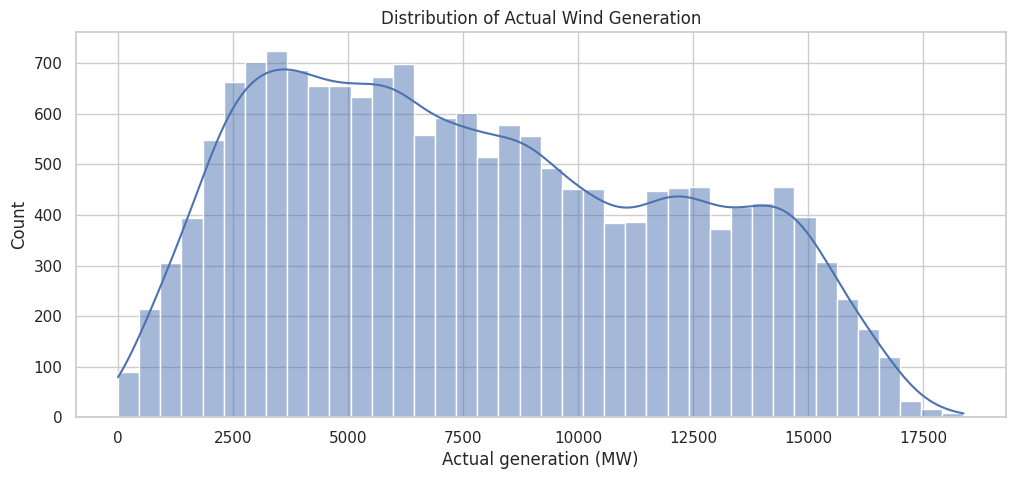

In [4]:
plt.figure(figsize=(12, 5))
sns.histplot(actuals["actual_mw"], bins=40, kde=True)
plt.title("Distribution of Actual Wind Generation")
plt.xlabel("Actual generation (MW)")
plt.ylabel("Count")
plt.show()


## Seasonal stress check

The recommendation should not be based only on the full-sample p10 if
one month is materially weaker than the rest.


In [5]:
monthly_summary = (
    actuals.groupby("month")
    .agg(
        sample_count=("target_time", "size"),
        mean_mw=("actual_mw", "mean"),
        p10_mw=("actual_mw", lambda s: s.quantile(0.10)),
        p05_mw=("actual_mw", lambda s: s.quantile(0.05)),
        min_mw=("actual_mw", "min"),
    )
    .reset_index()
)
monthly_summary


,month,sample_count,mean_mw,p10_mw,p05_mw,min_mw
0,1,1488,"8,188.38","2,493.80","1,867.40",86
1,2,1344,"9,505.13","4,495.70","3,768.50",1815
2,3,1488,"7,092.58","2,463.10","1,820.75",0
3,4,1440,"5,392.70","1,633.00","1,263.75",425
4,5,1488,"6,275.99","2,532.10","2,194.05",1488
5,6,1440,"7,511.90","3,184.10","1,721.05",658
6,7,1488,"4,460.53","1,564.50",986.85,0
7,8,1488,"5,978.41","1,673.50","1,128.35",659
8,9,1440,"8,843.10","3,709.60","2,822.80",197
9,10,1488,"8,924.30","1,793.10","1,158.05",391


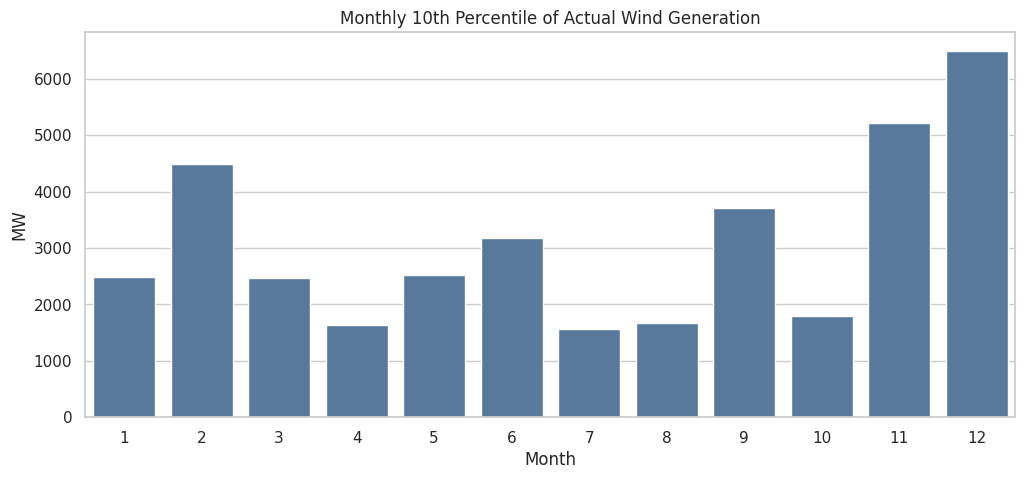

In [6]:
plt.figure(figsize=(12, 5))
sns.barplot(data=monthly_summary, x="month", y="p10_mw", color="#4c78a8")
plt.title("Monthly 10th Percentile of Actual Wind Generation")
plt.xlabel("Month")
plt.ylabel("MW")
plt.show()


## Recommendation

Recommendation rule used here:
- start from the weakest monthly 10th percentile,
- round down to the nearest 100 MW,
- treat that as a conservative dependable MW estimate.

In [7]:
weakest_monthly_p10 = monthly_summary["p10_mw"].min()
overall_p10 = actuals["actual_mw"].quantile(0.10)
recommended_mw = int(weakest_monthly_p10 // 100 * 100)
recommendation = pd.DataFrame(
    {
        "metric": [
            "overall_p10_mw",
            "weakest_monthly_p10_mw",
            "recommended_reliable_mw",
        ],
        "value": [
            overall_p10,
            weakest_monthly_p10,
            recommended_mw,
        ],
    }
)
recommendation

,metric,value
0,overall_p10_mw,"2,433.00"
1,weakest_monthly_p10_mw,"1,564.50"
2,recommended_reliable_mw,"1,500.00"


In [8]:
print(
    f"Recommended reliable wind availability: {recommended_mw:,} MW. "
    f"This is based on the weakest monthly 10th percentile "
    f"({weakest_monthly_p10:,.0f} MW), rounded down for conservatism."
    )


Recommended reliable wind availability: 1,500 MW. This is based on the weakest monthly 10th percentile (1,564 MW), rounded down for conservatism.


## Limitations

- If the historical sample is short, the recommendation is fragile.
- A stricter operational planning standard may prefer p05 instead of p10.
- This notebook uses delivered generation, so future fleet changes are not captured.
